# 마켓과 머신러닝
## 생선 분류 문제
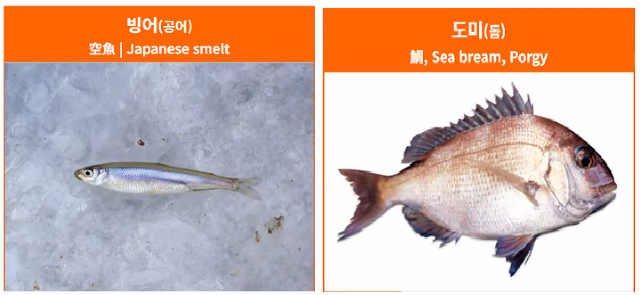
### 전통적인 프로그램과 머신러닝 프로그램 차이
1. 전통적인 프로그램
- 누군가가 사전에 규칙을 정해서 프로그램을 작성합니다.
- 예로 길이가 30섽티미터 이상이면 "도미"로 규정합니다.

    ```python
    # 코드로 형식 지정됨
    if fish_length > 30:
        print("도미)
    ```

2. 머신러닝 프로그램은 데이터를 통해 규칙을 스스로 찾게 해서 결과를 만듭니다.
    - 데이터에서 규칙을 찾는 과정을 **학습** 또는 **훈련**이라고 합니다.
    - 클래스는 머신러닝에서 분류하고자 하는 가각의 대상(범주)을 의미합니다.
        - 이진 분류 (Binary Classification): 도미와 빙어처럼 딱 2개 중 하나로 분류하는 경우입니다. (예: 스팸이다/아니다, 합격/불합격)
        - 다중 분류 (Multi-class Classification): 도미, 빙어, 연어, 고등어 등 3개 이상의 클래스로 분류하는 경우입니다.
    - 타깃(Target)은 모델이 예측하려는 정답 변수 전체 (y)를 의미합니다.
    - 모델(Model)이란 데이터(특성)을 입력받아 원하는 결과(타깃)를 예측하도록 학습된 규칙 또는 함수입니다.
    - 특성(Feature)이란 모델이 예측을 하기 위해 입력으로 사용하는 데이터의 속성(설명 변수)입니다.
        - 설명 변수(Explanatory Variable)란 결과(타깃)가 왜 그렇게 나왔는지를 설명하기 위해 사용하는 입력 변수입니다.
    
        예) 길이나 무게는 설명 변수, 결과 변수는 도미나 방어
---
### 도미 데이터 준비하기

In [1]:
# 35개의 데이터
# bream_length는 생선의 길이로 단위는 센티미터
# bream_weight는 생선의 무게로 단위는 그램
# 길이와 무게는 데이터의 특징(Feature)
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

---
### 산점도 그리기

도미 35마리를 2차원 그래프에 점으로 나타냅니다.

x축은 길이, y축은 무게입니다.

In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


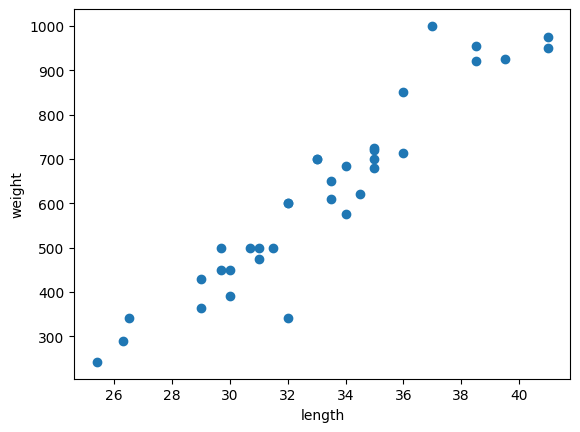

In [3]:
import matplotlib.pyplot as plt

plt.scatter(bream_length, bream_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

### 빙어 데이터 준비하기

In [4]:
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

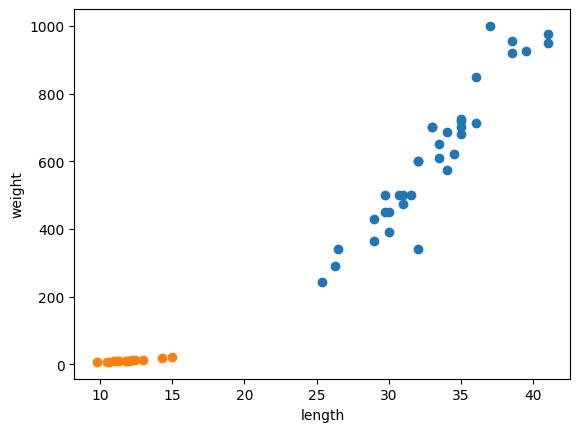

In [5]:
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

- 맷플롯립은 2개의 산점도를 색깔로 구분해서 나타냅니다.
- 주황색은 빙어, 파란색은 도미 입니다.
- 빙어는 길이가 늘어나더라도 무게가 많이 늘지 않습니다.
- 도미는 길이 늘면 무게도 증가하는 것을 확인할 수 있습니다.
---
## 데이터 합치기

In [6]:
length = bream_length + smelt_length
weight = bream_weight + smelt_weight

---
## 머신러닝의 대표적인 패키지인 scikit-learn은 입력 데이터를 2차원 배열 구조로 사용합니다.
이때 데이터의 형태는 (샘플 수 x 특성 수) 입니다.
- scikit-learn은 파이썬에서 머신러닝을 가장 쉽고 표준적인 방식으로 사용할 수 있게 해주는 라이브러리로 모든 모델이 fit()과 predict()라는 동일한 인터페이스를 통해 학습과 예측을 수행합니다.
- 여러 개의 1차원 데이터는 파이썬의 zip() 함수와 리스트 컴프리헨션을 사용하여 scikit-learn에서 요구하는 (샘플 수 x 특성 수) 형태의 2차원 입력 데이터로 쉽게 결합할 수 있습니다.

In [7]:
fish_data = [[l, w] for l, w in zip(length, weight)]
print(fish_data)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]


---
답을 만들기 위한 데이터

In [8]:
# 1은 도미, 0은 빙어를 의미합니다.
fish_target = [1]*35 + [0]*14
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [9]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
kn = KNeighborsClassifier()

In [14]:
import numpy as np
fish_data = np.array(fish_data)
kn.fit(fish_data, fish_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
kn.score(fish_data, fish_target)

1.0

---
### k-최근접 이웃 알고리즘
아래의 새로운 데이터가 [30, 600]인 경우 도미 또는 빙어 중 무엇일까요?
- 새로운 데이터를 예측하기 위한 과정
    1. 새 데이터 [30, 600]과 저장된 모든 fish_data 간의 거리 계산
    2. 가장 가까운 K개의 샘플을 선택
    3. 그 K개의 클래스 중 가장 많이 등장한 클래스를 결과로 반환

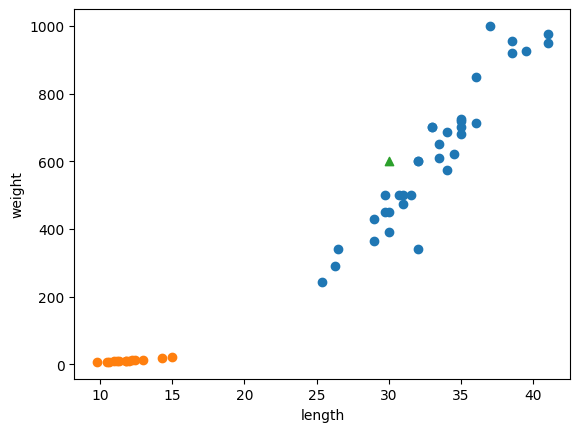

In [16]:
new_data = np.array([30, 600])
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
plt.scatter(new_data[0], new_data[1], marker='^') # Triangle marker
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [21]:
distances, indexes = kn.kneighbors(new_data.reshape(1, new_data.size))
print(distances)
print(indexes)

[[ 2.          2.         10.59481005 20.5        25.3179778 ]]
[[15 14 18 22 20]]


In [22]:
print(indexes[0])

neighbors = [fish_data[i] for i in indexes[0]]
print(neighbors)

[15 14 18 22 20]
[array([ 32., 600.]), array([ 32., 600.]), array([ 33.5, 610. ]), array([ 34.5, 620. ]), array([ 34., 575.])]


In [23]:
print(type(neighbors))

<class 'list'>


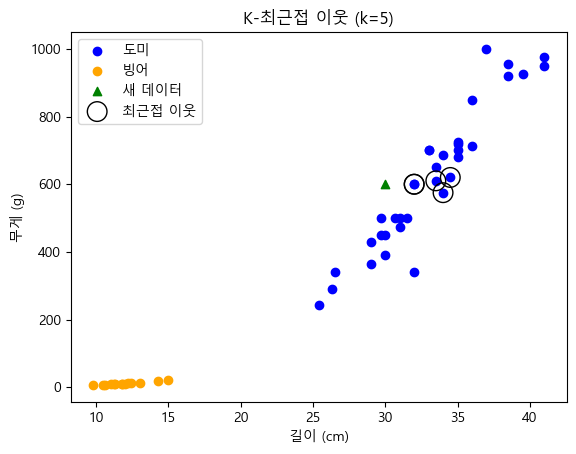

In [66]:
# 새로운 데이터를 예측합니다.
# [[30, 600]] 처럼 매개 변수는 리스트 안에 리스트로 전달해야 합니다.
# 결과는 1 => 도미
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

neighbors = np.array(neighbors) # NumPy 배열로 변환

plt.scatter(bream_length, bream_weight, c='blue')
plt.scatter(smelt_length, smelt_weight, c='orange')
plt.scatter(new_data[0], new_data[1], marker='^', c='green')
plt.scatter(neighbors[:, 0], neighbors[:, 1], marker='o', s=200, ec='black', fc='none')
plt.title('K-최근접 이웃 (k=5)')
plt.xlabel('길이 (cm)')
plt.ylabel('무게 (g)')
plt.legend(['도미', '빙어', '새 데이터', '최근접 이웃'])
plt.show()